In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.multiclass import OneVsRestClassifier
import numpy as np

In [13]:

iris_df = pd.read_csv('/content/iris.csv')

X_iris = iris_df.iloc[:, :-1]
y_iris = iris_df.iloc[:, -1]

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.20, random_state=42)

In [16]:

letter_df = pd.read_csv('/content/letter-recognition.csv')

X_letter = letter_df.iloc[:, 1:]
y_letter = letter_df.iloc[:, 0]

X_train_letter, X_test_letter, y_train_letter, y_test_letter = train_test_split(X_letter, y_letter, test_size=0.20, random_state=42)

### 3. Random Forest Classifier for IRIS Flower Dataset

Accuracy Score with n_estimators=10: 1.0000

Confusion Matrix (n_estimators=10):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


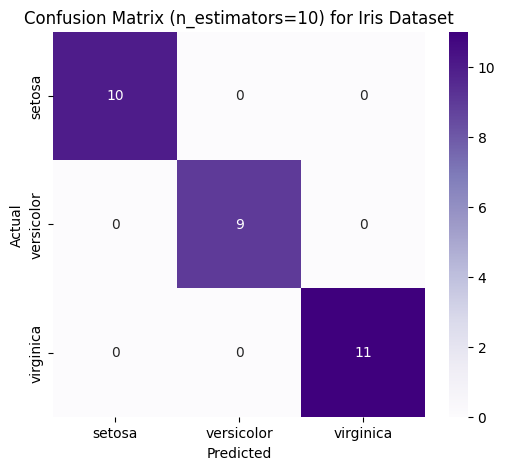

In [24]:
from sklearn.ensemble import RandomForestClassifier



rf_classifier_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_classifier_default.fit(X_train_iris, y_train_iris)

y_pred_rf_default = rf_classifier_default.predict(X_test_iris)

accuracy_rf_default = accuracy_score(y_test_iris, y_pred_rf_default)
print(f"Accuracy Score with n_estimators=10: {accuracy_rf_default:.4f}")

conf_matrix_rf_default = confusion_matrix(y_test_iris, y_pred_rf_default)
print("\nConfusion Matrix (n_estimators=10):")
print(conf_matrix_rf_default)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf_default, annot=True, fmt='d', cmap='Purples',
            xticklabels=rf_classifier_default.classes_, yticklabels=rf_classifier_default.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (n_estimators=10) for Iris Dataset')
plt.show()

#### Fine-tuning `n_estimators` for Random Forest


Best Accuracy Score: 1.0000
Achieved with n_estimators: 1


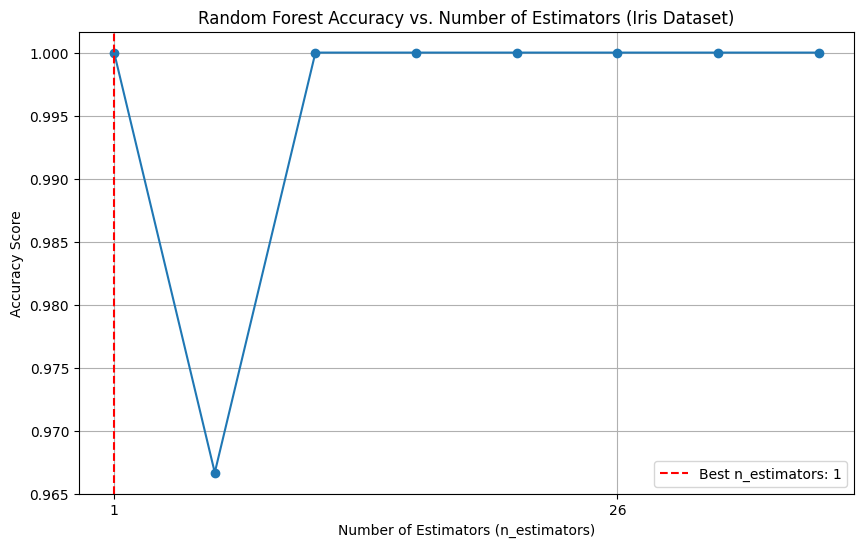


Confusion Matrix (Best n_estimators=1):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


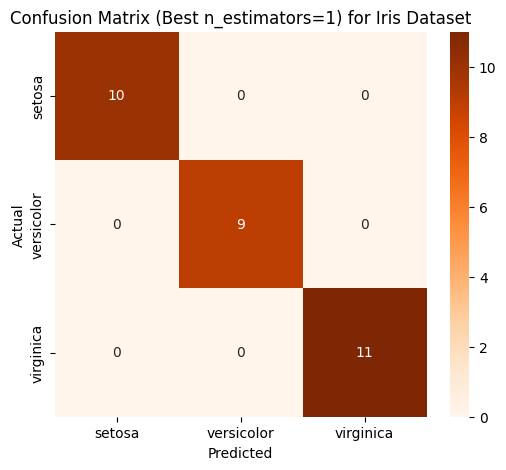

In [25]:


n_estimators_range = range(1, 40, 5)
accuracies = []

for n_est in n_estimators_range:
    rf_classifier = RandomForestClassifier(n_estimators=n_est, random_state=42)
    rf_classifier.fit(X_train_iris, y_train_iris)
    y_pred = rf_classifier.predict(X_test_iris)
    accuracies.append(accuracy_score(y_test_iris, y_pred))

best_accuracy = max(accuracies)
best_n_estimators = n_estimators_range[accuracies.index(best_accuracy)]

print(f"\nBest Accuracy Score: {best_accuracy:.4f}")
print(f"Achieved with n_estimators: {best_n_estimators}")

plt.figure(figsize=(10, 6))
plt.plot(list(n_estimators_range), accuracies, marker='o', linestyle='-')
plt.title('Random Forest Accuracy vs. Number of Estimators (Iris Dataset)')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.xticks(list(n_estimators_range)[::5]) # Show fewer x-ticks for readability
plt.axvline(x=best_n_estimators, color='r', linestyle='--', label=f'Best n_estimators: {best_n_estimators}')
plt.legend()
plt.show()

rf_classifier_best = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42)
rf_classifier_best.fit(X_train_iris, y_train_iris)
y_pred_rf_best = rf_classifier_best.predict(X_test_iris)
conf_matrix_rf_best = confusion_matrix(y_test_iris, y_pred_rf_best)

print(f"\nConfusion Matrix (Best n_estimators={best_n_estimators}):")
print(conf_matrix_rf_best)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_rf_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=rf_classifier_best.classes_, yticklabels=rf_classifier_best.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Best n_estimators={best_n_estimators}) for Iris Dataset')
plt.show()